# EDA — ValorAuto

Analisis exploratorio del Craigslist Vehicles Dataset. Este notebook es delgado: solo llama funciones de `src/model/eda/` y `src/model/cleaning.py`, no tiene logica propia (ver [ADR-0008](../docs/adr/0008-separacion-componentes-notebooks-delgados.md)). Los graficos se guardan en `src/graphics/eda/`.

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Busca la raiz del repo subiendo desde `start` hasta encontrar `src/` y `notebooks/`.

    No asume un cwd fijo (a diferencia de `Path.cwd().parent`, que solo
    funciona si el notebook se lanzo con cwd=notebooks/): sirve tanto si
    Jupyter arranca con cwd en la carpeta del notebook como si se ejecuta
    con nbconvert/papermill desde la raiz del repo u otra carpeta.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError(
        "No se pudo ubicar la raiz del repo (se buscaron 'src/' y 'notebooks/' "
        f"subiendo desde {start})."
    )


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [2]:
from IPython.display import Image, display

from src.model import cleaning, data_loading
from src.model.eda import categorias, correlaciones, distribuciones, nulos, outliers


## 1. Carga del dataset crudo y reporte de nulos

Dimensiones del dataset crudo: (426880, 12)


,valores_faltantes,porcentaje
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
drive,130567,30.586347
type,92858,21.752717
manufacturer,17646,4.133714
model,5277,1.236179
odometer,4400,1.030735
fuel,3013,0.705819
transmission,2556,0.598763


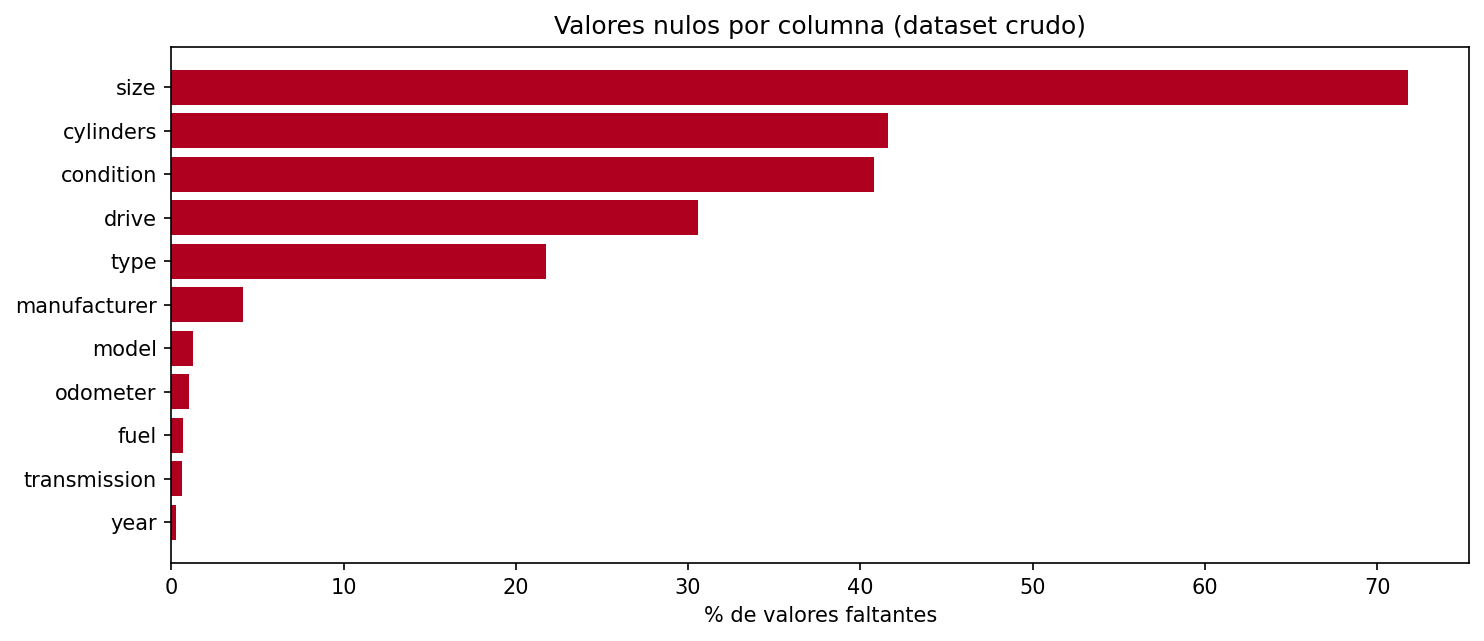

In [3]:
df_raw = data_loading.load_raw()
print(f"Dimensiones del dataset crudo: {df_raw.shape}")

display(nulos.reporte_nulos(df_raw))
ruta_nulos = nulos.graficar_nulos(df_raw)
display(Image(filename=ruta_nulos))


## 2. Limpieza

Reglas centralizadas en `src/model/cleaning.py` (parametrizadas desde `src/model/config.py`), no hardcodeadas en esta celda.

In [4]:
df_clean, reporte = cleaning.clean_dataset(df_raw)
print(f"Filas iniciales: {reporte['filas_iniciales']}")
print(f"Descartadas por precio: {reporte['descartadas_por_precio']}")
print(f"Descartadas por anio: {reporte['descartadas_por_anio']}")
print(f"Descartadas por odometro: {reporte['descartadas_por_odometro']}")
print(f"Descartadas por marca/modelo nulos: {reporte['descartadas_por_marca_modelo']}")
print(f"Filas finales: {reporte['filas_finales']} ({reporte['porcentaje_descartado']}% descartado en total)")

ruta_guardado = cleaning.save_clean(df_clean)
print(f"Dataset limpio guardado en: {ruta_guardado}")


Filas iniciales: 426880
Descartadas por precio: 43812
Descartadas por anio: 12908
Descartadas por odometro: 3493
Descartadas por marca/modelo nulos: 14662
Filas finales: 352005 (17.54% descartado en total)


Dataset limpio guardado en: /app/data/vehicles/vehicles_clean.csv


## 3. Exploracion sobre el dataset limpio

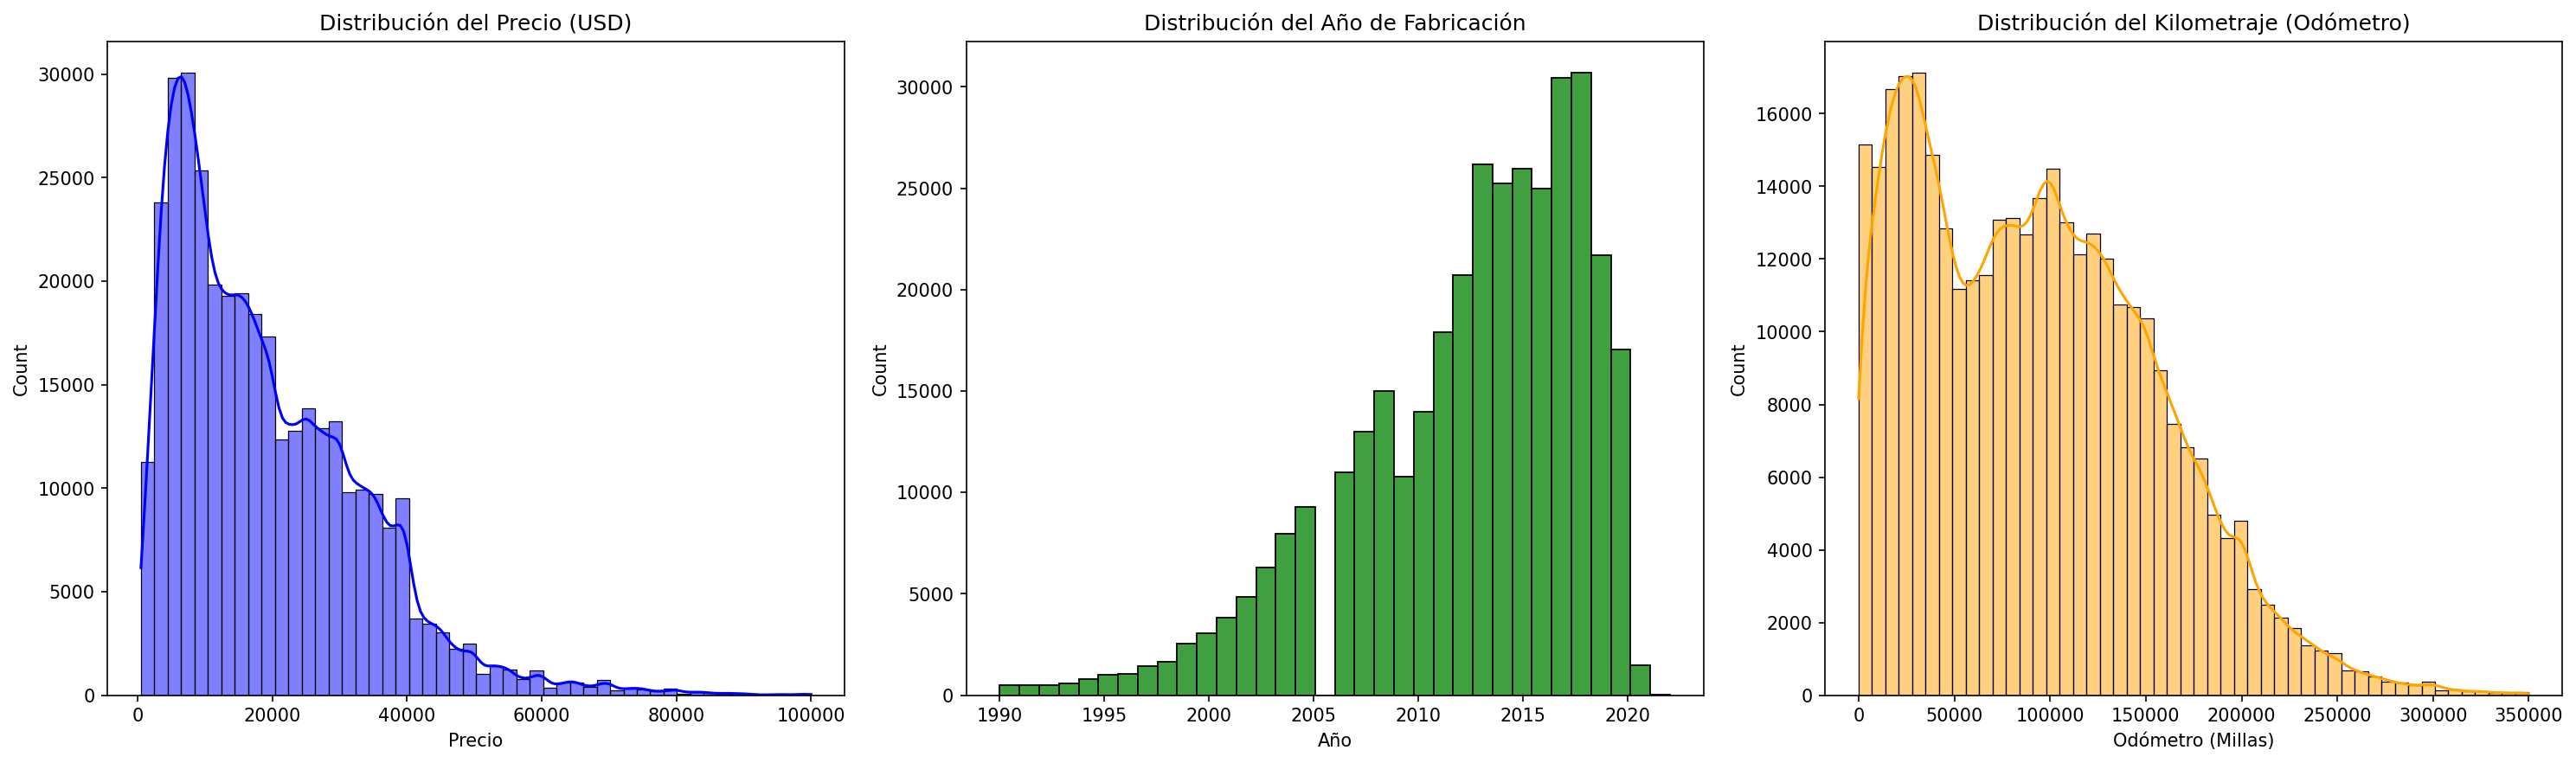

In [5]:
ruta_dist = distribuciones.graficar_distribuciones(df_clean)
display(Image(filename=ruta_dist))


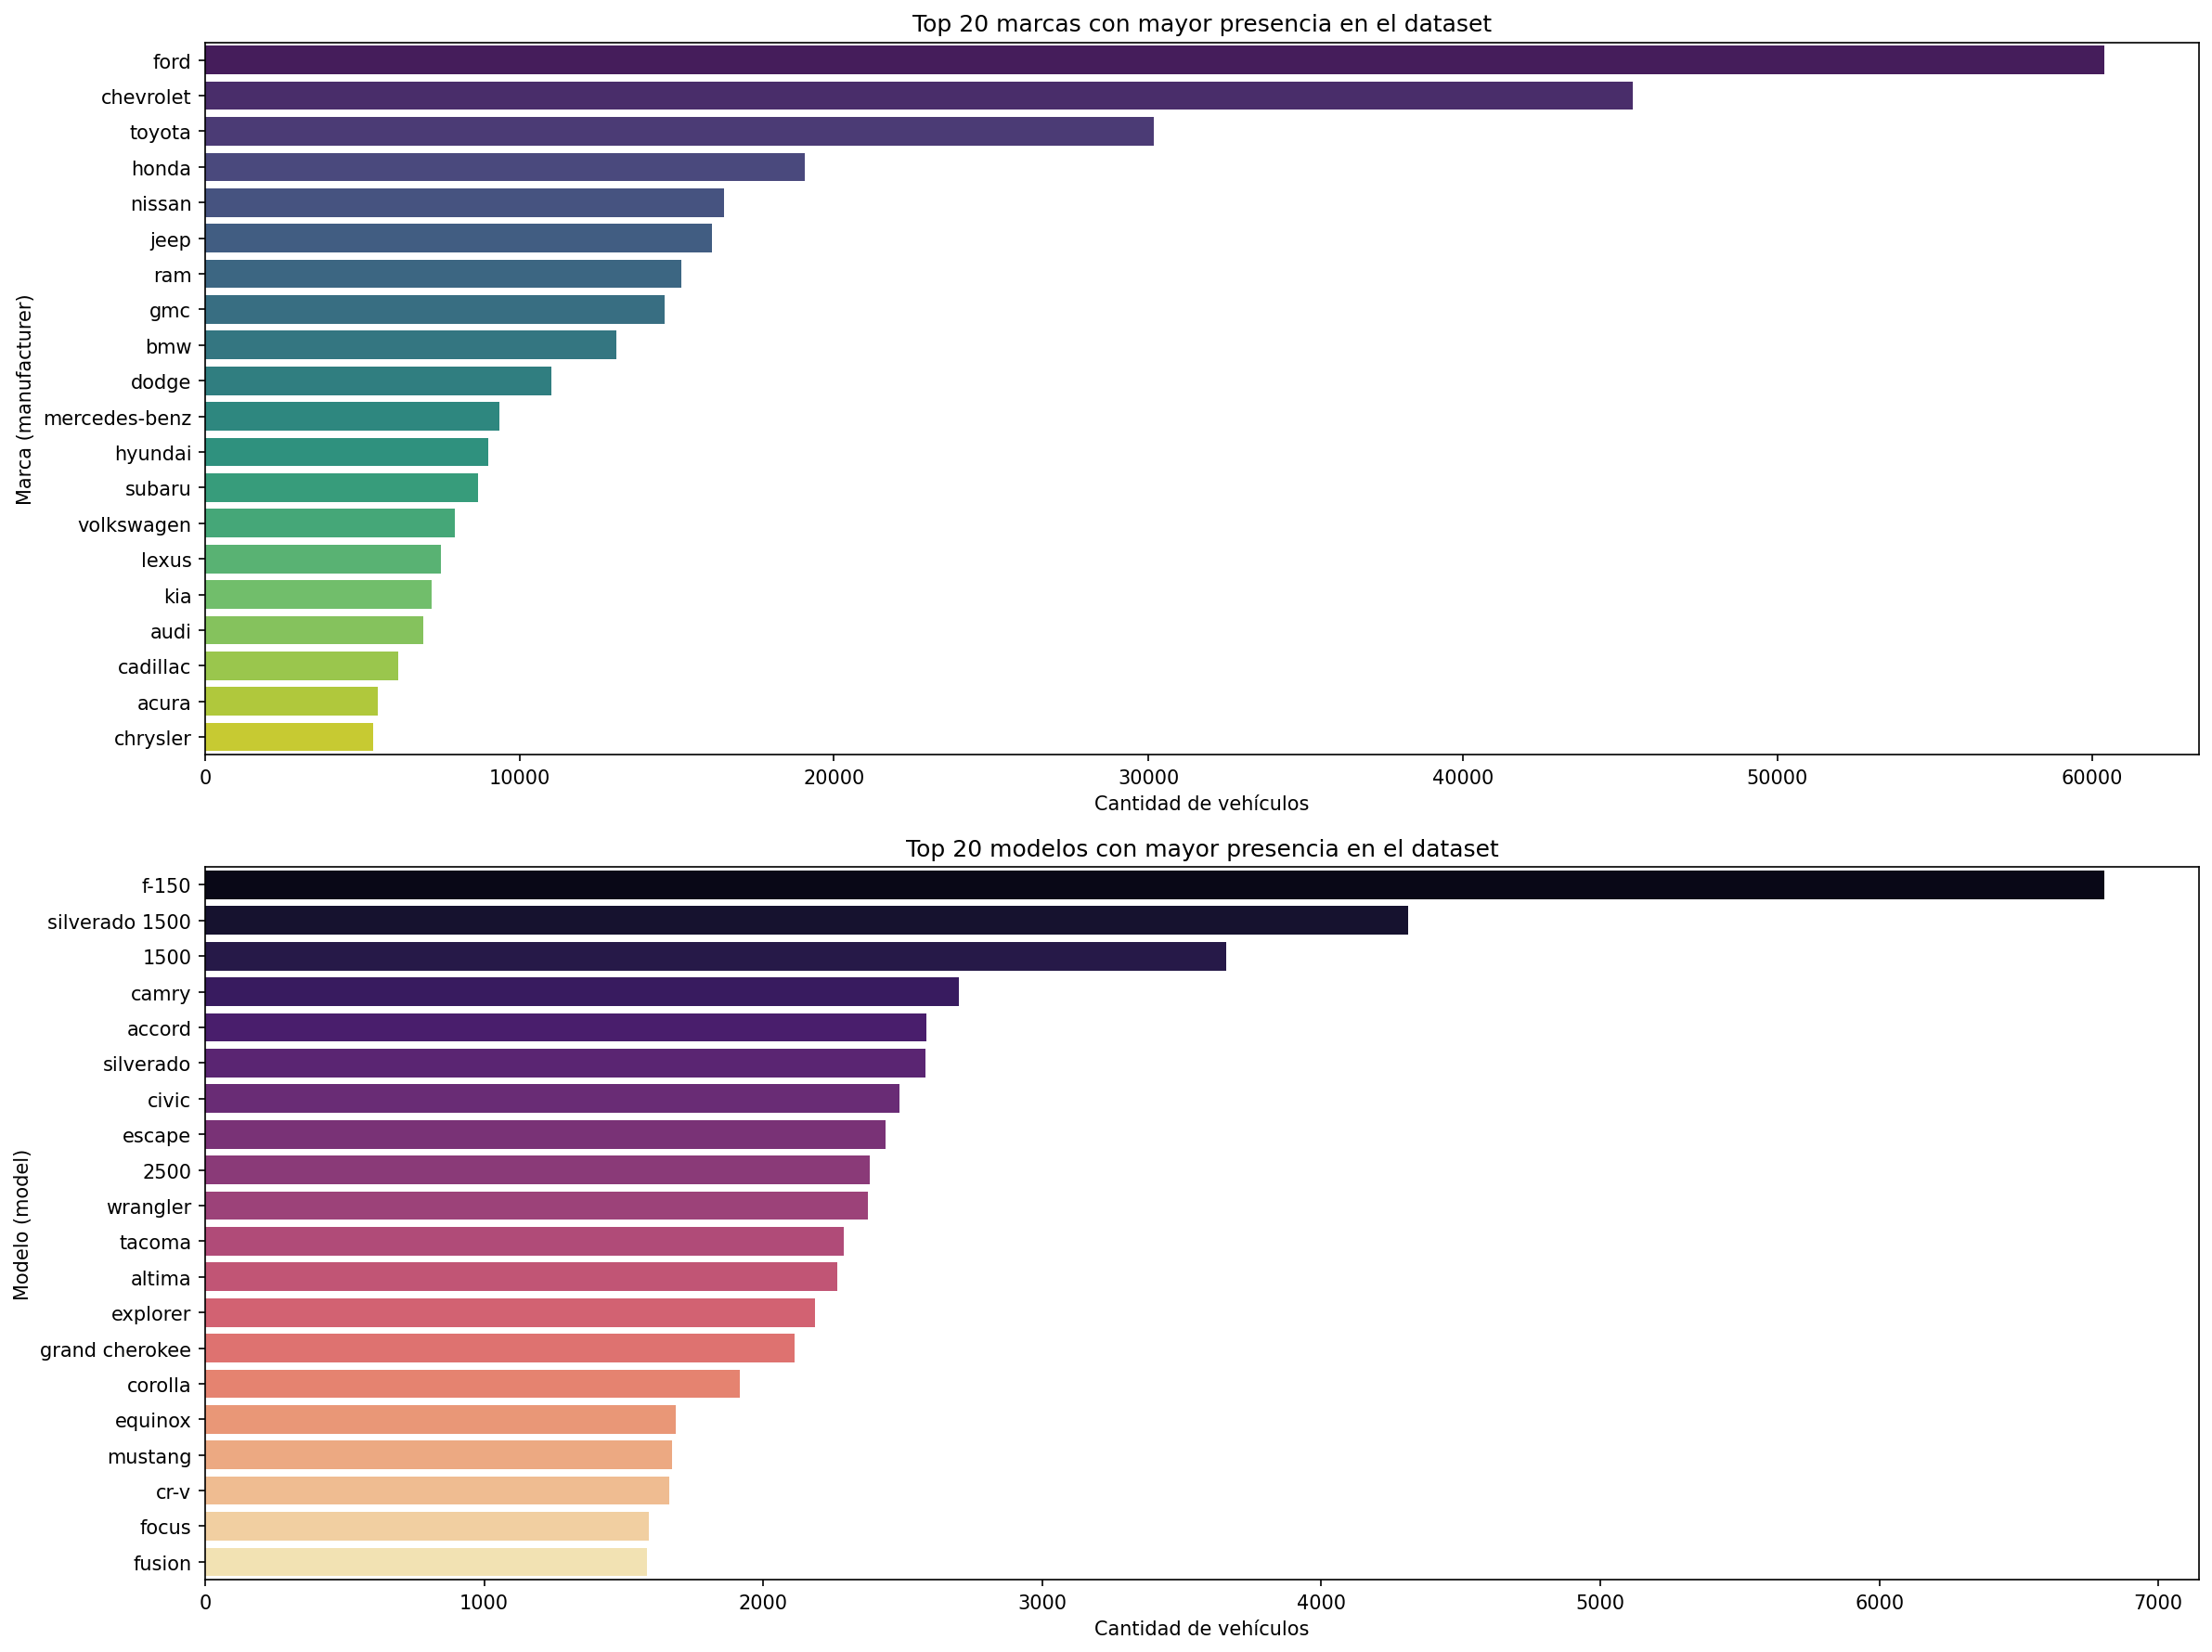

In [6]:
ruta_top = categorias.graficar_top_categorias(df_clean)
display(Image(filename=ruta_top))


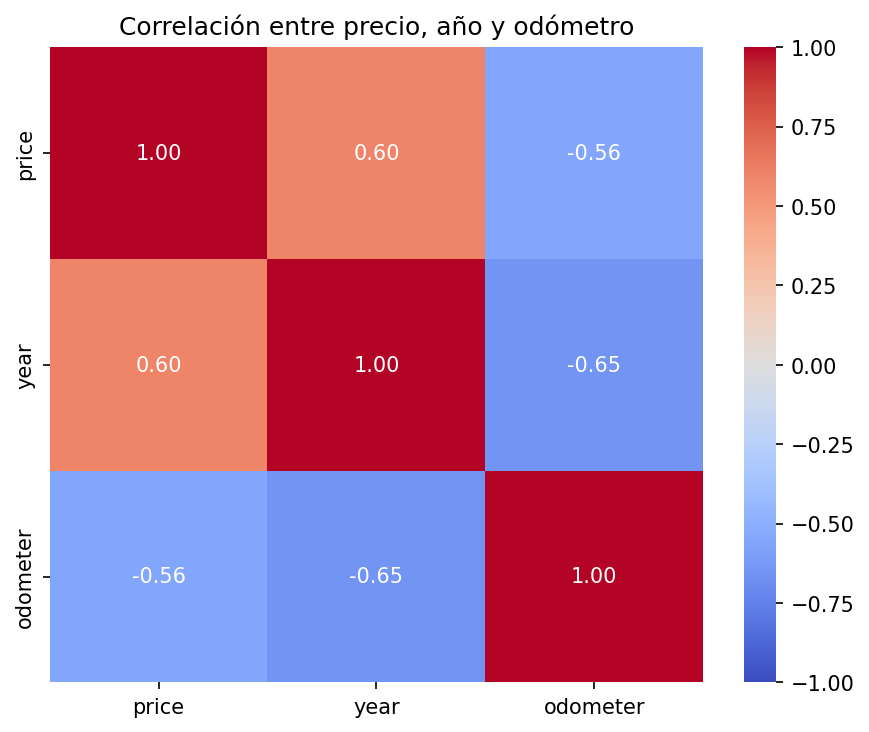

In [7]:
ruta_corr = correlaciones.graficar_correlaciones(df_clean)
display(Image(filename=ruta_corr))


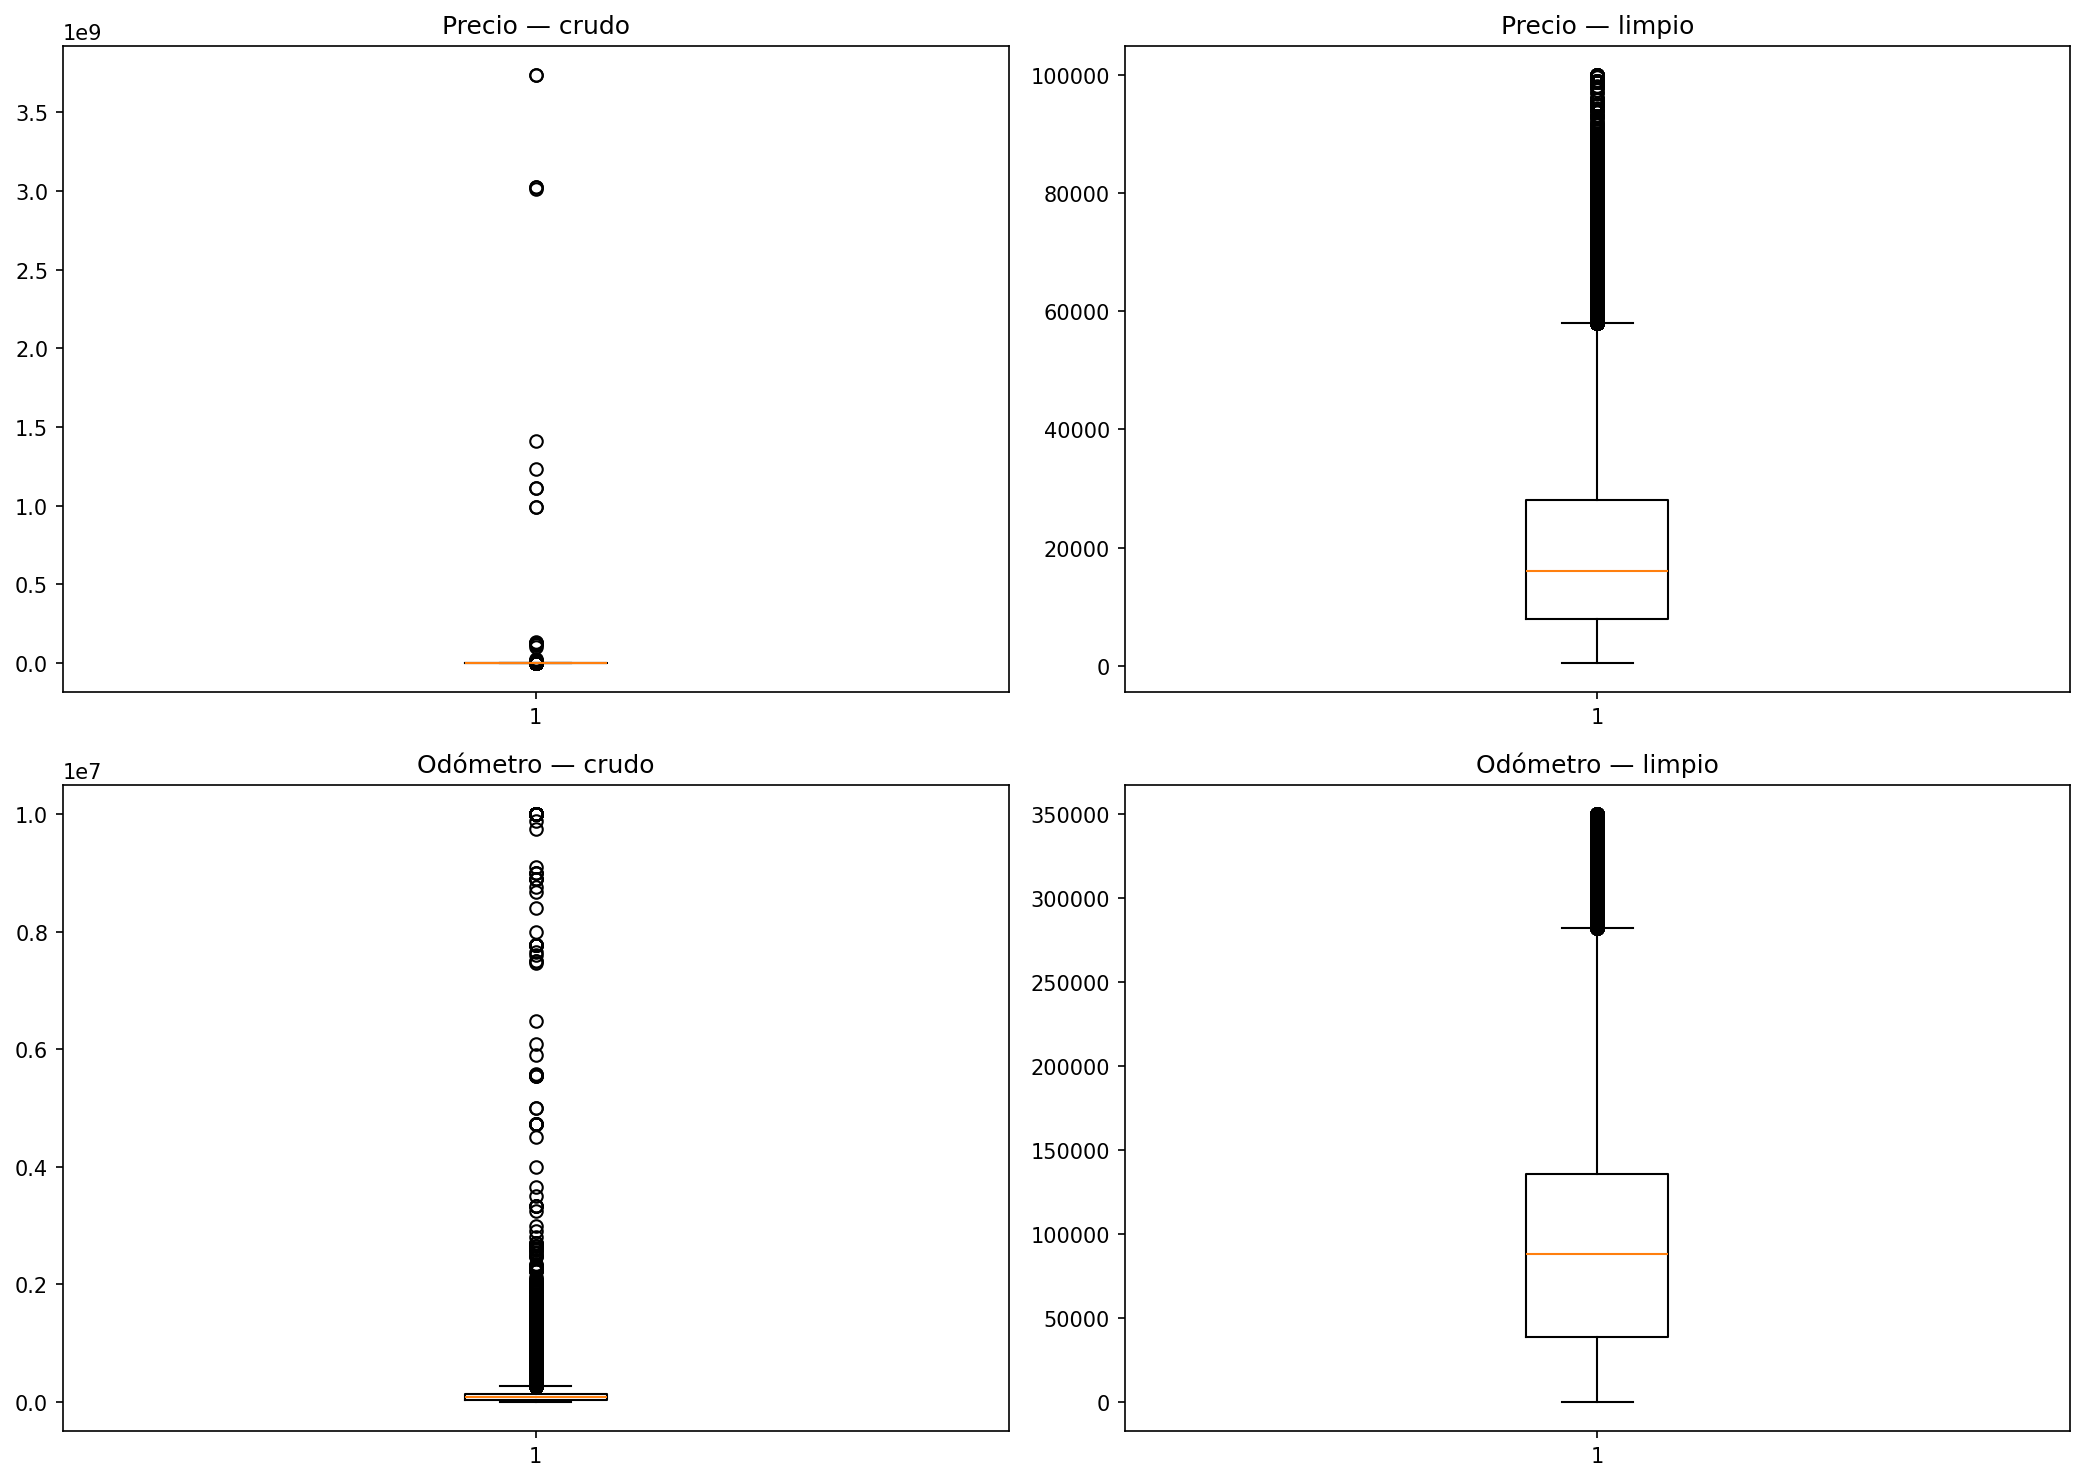

In [8]:
ruta_outliers = outliers.graficar_outliers(df_raw, df_clean)
display(Image(filename=ruta_outliers))


## Evidencia generada

Todos los graficos de esta seccion quedan guardados y versionados en `src/graphics/eda/`, listos para revisar en vivo o citar en la presentacion.